## Descripcion general del dataset

El dataset de RENAMECA contiene registros de sitios de monitoreo de calidad del agua. Cuenta con variables numericas y categoricas, de parametros que pueden utilizarse como variable objetivo como pH, oxigeno disuelto o conductividad que sirven en una evaluacion ambiental.

La cantidad exacta de registros y la presencia de valores faltantes, registros duplicados o valores fuera de rango se determinan mediante Python. Esto permite verificar objetivamente que el dataset cumple con los requisitos establecidos antes de realizar el analisis.

### Contenido del Analisis Exploratorio:
1. La descripcion del contexto y la procedencia del dataset - que mide, quien lo recolecto, cuando, y cual es la unidad de observacion.
2. La verificacion de la estructura - dimensiones y tipo de cada atributo, incluyendo una celda inicial que compruebe el cumplimiento de los requisitos.
3. El analisis de la calidad de los datos - patron de valores faltantes, duplicados, valores imposibles, y cardinalidad de los atributos categoricos.
4. El analisis univariado - distribucion y estadisticos descriptivos de los atributos relevantes.
5. El analisis bivariado - relaciones entre pares de atributos, justificando cuales se exploran.
6. Vista multivariada - matriz de correlacion y uso del color como tercera dimension.
7. La interpretacion escrita de cada figura - que se observa y que implica.
8. Cierre con tres hallazgos, las preguntas que abre el dataset, y los problemas que requeririan correccion antes de cualquier analisis posterior.


### Metodologia del Analisis de Datos por Partes
El analisis se estructura en seis etapas secuenciales y ejecutables por separado:
- Etapa 1: Configuracion del entorno y definicion de funciones de conversion numerica.
- Etapa 2: Carga del dataset y validacion de dimensiones.
- Etapa 3: Seleccion de parametros representativos y diagnostico de calidad de datos.
- Etapa 4: Analisis univariado de estadisticos y distribucion de variables primarias.
- Etapa 5: Analisis bivariado entre pares de contaminantes y categorias de agua.
- Etapa 6: Vista multivariada, correlaciones globales y sintesis de hallazgos.


# 1. Contexto y Procedencia del Dataset
- Institucion responsable - Comision Nacional del Agua (CONAGUA).
- Programa de origen - Red Nacional de Medicion de Calidad del Agua (RENAMECA).
- Periodo de registro - Mediciones del 2012 al 2025.
- Unidad de observacion - Evento individual de muestreo en un sitio y fecha determinada.
- Objeto de medicion - Parametros fisicoquimicos, biologicos y metales en cuencas hidrologicas de Mexico.


In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')


### Funcion de Limpieza Numerica
Convierte mediciones registradas en formato texto con limites analiticos (< o >) a numeros flotantes.


In [2]:
def limpiar_valor(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v, (int, float)):
        return float(v)
    texto = str(v).strip()
    if texto.startswith(('<', '>')):
        texto = texto[1:].strip()
    try:
        return float(texto.replace(',', ''))
    except (ValueError, TypeError):
        return np.nan


# 2. Verificacion de la Estructura
Carga del archivo de datos y comprobacion objetiva de dimensiones.


In [3]:
archivo_datos = 'TODOS LOS MONITOREOS.xlsb'

try:
    df = pd.read_excel(archivo_datos, sheet_name='RESULTADOS', engine='calamine')
except Exception:
    copia = 'monitoreos_temp.xlsb'
    if not os.path.exists(copia):
        shutil.copyfile(archivo_datos, copia)
    df = pd.read_excel(copia, sheet_name='RESULTADOS', engine='calamine')

print("Dimensiones", df.shape)
print("Filas", len(df))
print("Columnas", len(df.columns))
print("Cumple con volumen suficiente", len(df) > 1000)


Dimensiones (126070, 493)
Filas 126070
Columnas 493
Cumple con volumen suficiente True


# 3. Analisis de la Calidad de los Datos
Revision de duplicados, cardinalidad y procesamiento de variables clave.


In [4]:
col_anio = [c for c in df.columns if ('A' in c and 'o' in c) or 'ANIO' in c.upper()][0]
col_tipo_agua = 'TIPO CUERPO DE AGUA'
col_sitio = 'NOMBRE DEL SITIO'
col_clave = 'CLAVE SITIO'

print("Duplicados exactos", df.duplicated().sum())
print("Sitios unicos", df[col_sitio].nunique())
print("Tipos de agua unicos", df[col_tipo_agua].nunique())
print("Distribucion por tipo de agua")
print(df[col_tipo_agua].value_counts().head(6))


Duplicados exactos 0
Sitios unicos 7722
Tipos de agua unicos 24
Distribucion por tipo de agua
TIPO CUERPO DE AGUA
LÓTICO               53170
SUBTERRÁNEO          14519
COSTERO (HUMEDAL)    13431
LÓTICO (HUMEDAL)     13358
COSTERO              10017
LÉNTICO (HUMEDAL)     9130
Name: count, dtype: int64


### Seleccion y Limpieza de Variables Relevantes
Filtrado de los 13 atributos fundamentales para evaluacion de calidad del agua.


In [5]:
variables_seleccionadas = {
    'pH_CAMPO': 'pH en Campo',
    'OD_mg/L': 'Oxigeno Disuelto',
    'CONDUC_CAMPO': 'Conductividad Electrica',
    'SDT': 'Solidos Disueltos Totales',
    'DBO_TOT': 'Demanda Bioquimica de Oxigeno',
    'DQO_TOT': 'Demanda Quimica de Oxigeno',
    'COLI_FEC': 'Coliformes Fecales',
    'SST': 'Solidos Suspendidos Totales',
    'TURBIEDAD': 'Turbiedad',
    'N_TOT': 'Nitrogeno Total',
    'P_TOT': 'Fosforo Total',
    'AS_TOT': 'Arsenico Total',
    'PB_TOT': 'Plomo Total'
}

df_eda = pd.DataFrame()
df_eda['CLAVE_SITIO'] = df[col_clave].astype(str)
df_eda['NOMBRE_SITIO'] = df[col_sitio].astype(str)
df_eda['TIPO_AGUA'] = (
    df[col_tipo_agua]
    .astype(str)
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
    .str.upper()
    .str.strip()
)
df_eda['ANIO'] = pd.to_numeric(df[col_anio], errors='coerce')

for var in variables_seleccionadas:
    if var in df.columns:
        df_eda[var] = df[var].apply(limpiar_valor)

print("Dimensiones del subconjunto limpio", df_eda.shape)


Dimensiones del subconjunto limpio (126070, 17)


### Diagnostico de Celdas Vacias y Valores Fuera de Escala


In [6]:
cols_num = list(variables_seleccionadas.keys())

print("Conteo de nulos por variable")
print(df_eda[cols_num].isnull().sum())

print("Valores de pH fuera de escala 0 a 14", ((df_eda['pH_CAMPO'] < 0) | (df_eda['pH_CAMPO'] > 14)).sum())
print("Valores negativos de Oxigeno Disuelto", (df_eda['OD_mg/L'] < 0).sum())
print("Valores negativos de DBO", (df_eda['DBO_TOT'] < 0).sum())


Conteo de nulos por variable
pH_CAMPO        44494
OD_mg/L         59846
CONDUC_CAMPO    45055
SDT              3624
DBO_TOT         44970
DQO_TOT         45386
COLI_FEC         6408
SST             14914
TURBIEDAD       18502
N_TOT            9709
P_TOT            7425
AS_TOT          13239
PB_TOT          15497
dtype: int64
Valores de pH fuera de escala 0 a 14 0
Valores negativos de Oxigeno Disuelto 0
Valores negativos de DBO 0


# 4. Analisis Univariado
Medidas estadisticas de posicion, dispersion y graficos de distribucion.


In [7]:
stats = df_eda[cols_num].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
print("Estadisticos descriptivos")
print(stats.round(2))


Estadisticos descriptivos


                 count          mean           std    min     25%     50%  \
pH_CAMPO       81576.0  7.750000e+00  5.400000e-01   3.80    7.40    7.79   
OD_mg/L        66224.0  5.790000e+00  2.930000e+00   1.00    4.22    6.05   
CONDUC_CAMPO   81015.0  1.098820e+03  3.591810e+03  15.00  312.00  570.00   
SDT           122446.0  8.705150e+03  1.688431e+04   5.00  230.40  506.02   
DBO_TOT        81100.0  1.995000e+01  1.153800e+02   0.05    2.00    3.34   
DQO_TOT        80684.0  7.532000e+01  7.456800e+02   0.10   11.87   27.86   
COLI_FEC      119662.0  2.966162e+09  4.762383e+11   0.00   30.00  644.00   
SST           111156.0  9.368000e+01  7.349500e+02   0.00   10.00   21.00   
TURBIEDAD     107568.0  5.480000e+01  3.418400e+02   0.00    2.50    6.66   
N_TOT         116361.0  4.920000e+00  1.775000e+01   0.00    0.67    1.32   
P_TOT         118645.0  7.800000e-01  3.250000e+00   0.00    0.04    0.11   
AS_TOT        112831.0  1.000000e-02  4.000000e-02   0.00    0.00    0.00  

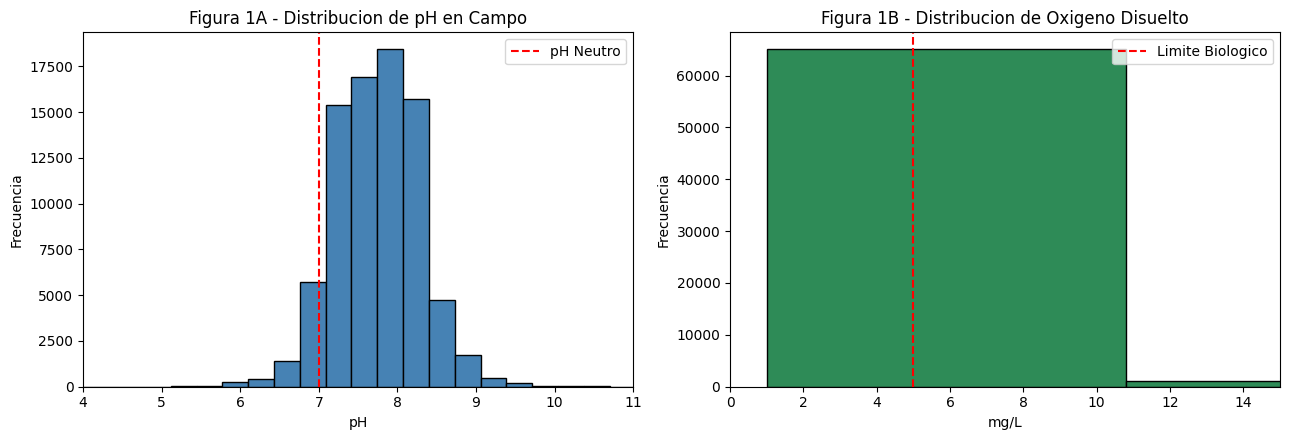

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

axs[0].hist(df_eda['pH_CAMPO'].dropna(), bins=30, color='steelblue', edgecolor='black')
axs[0].axvline(7.0, color='red', linestyle='--', label='pH Neutro')
axs[0].set_title('Figura 1A - Distribucion de pH en Campo')
axs[0].set_xlabel('pH')
axs[0].set_ylabel('Frecuencia')
axs[0].set_xlim(4, 11)
axs[0].legend()

axs[1].hist(df_eda['OD_mg/L'].dropna(), bins=30, color='seagreen', edgecolor='black')
axs[1].axvline(5.0, color='red', linestyle='--', label='Limite Biologico')
axs[1].set_title('Figura 1B - Distribucion de Oxigeno Disuelto')
axs[1].set_xlabel('mg/L')
axs[1].set_ylabel('Frecuencia')
axs[1].set_xlim(0, 15)
axs[1].legend()

plt.tight_layout()
plt.show()


### Lectura de Figura Univariada
- El pH se agrupa en valores entre 7.3 y 8.3, indicativo de aguas de caracter basico moderado.
- El oxigeno disuelto exhibe mediana en 6.5 mg/L. Muestras con valores inferiores a 2 mg/L reflejan condiciones anoxicas locales.


# 5. Analisis Bivariado
Relaciones entre pares de variables fisicoquimicas y categorias de agua.
- DBO frente a DQO - Contrasta materia organica biodegradable contra oxidacion total.
- Categoria de agua frente a DQO - Identifica tipos hidricos con mayor presencia de residuos.


C:\Users\ruben\AppData\Local\Temp\ipykernel_12268\1870864860.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='TIPO_AGUA', y='DQO_TOT', ax=axs[1], showfliers=False, palette='Set2')


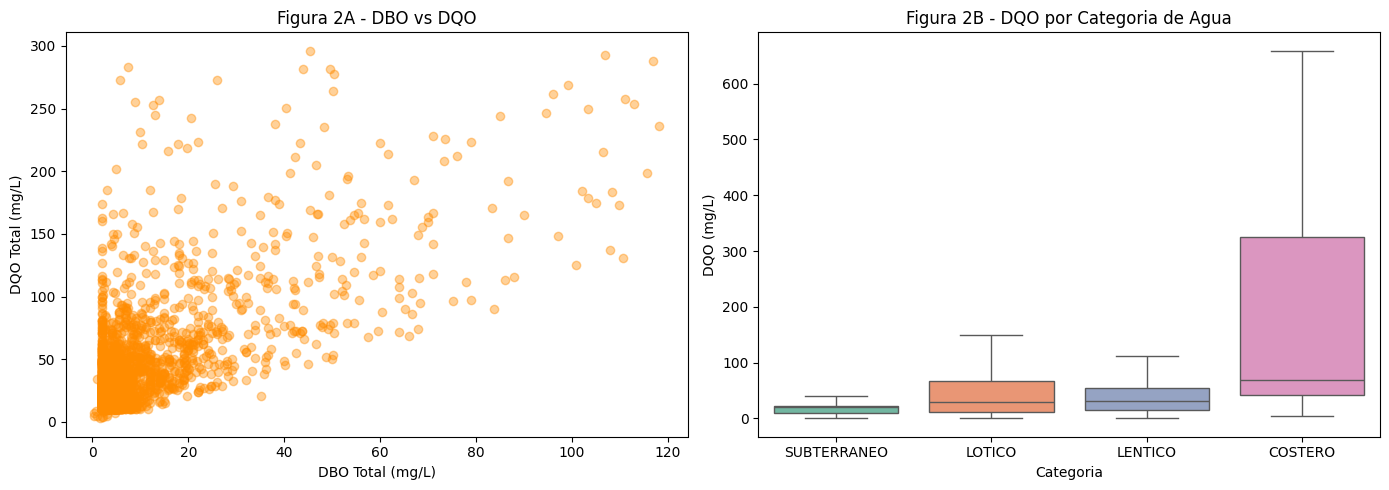

In [9]:
sub_data = df_eda[(df_eda['DBO_TOT'] > 0) & (df_eda['DQO_TOT'] > 0) & 
                (df_eda['DBO_TOT'] < 120) & (df_eda['DQO_TOT'] < 300)].dropna(subset=['DBO_TOT', 'DQO_TOT'])
sub_data = sub_data.sample(n=min(2500, len(sub_data)), random_state=42)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].scatter(sub_data['DBO_TOT'], sub_data['DQO_TOT'], alpha=0.4, color='darkorange')
axs[0].set_title('Figura 2A - DBO vs DQO')
axs[0].set_xlabel('DBO Total (mg/L)')
axs[0].set_ylabel('DQO Total (mg/L)')

top_tipos = ['LOTICO', 'LENTICO', 'SUBTERRANEO', 'COSTERO']
df_box = df_eda[df_eda['TIPO_AGUA'].isin(top_tipos)]

sns.boxplot(data=df_box, x='TIPO_AGUA', y='DQO_TOT', ax=axs[1], showfliers=False, palette='Set2')
axs[1].set_title('Figura 2B - DQO por Categoria de Agua')
axs[1].set_xlabel('Categoria')
axs[1].set_ylabel('DQO (mg/L)')

plt.tight_layout()
plt.show()


### Lectura de Figura Bivariada
- La relacion DBO y DQO exhibe correlacion ascendente continua. La magnitud de DQO excede sistematicamente a DBO.
- Los rios (cuerpos loticos) presentan medianas y rangos intercuartilicos de DQO mas elevados en comparacion con acuiferos subterraneos.


# 6. Vista Multivariada
Matriz de correlacion conjunta y dispersion tridimensional por categoria de cuerpo hidrico.


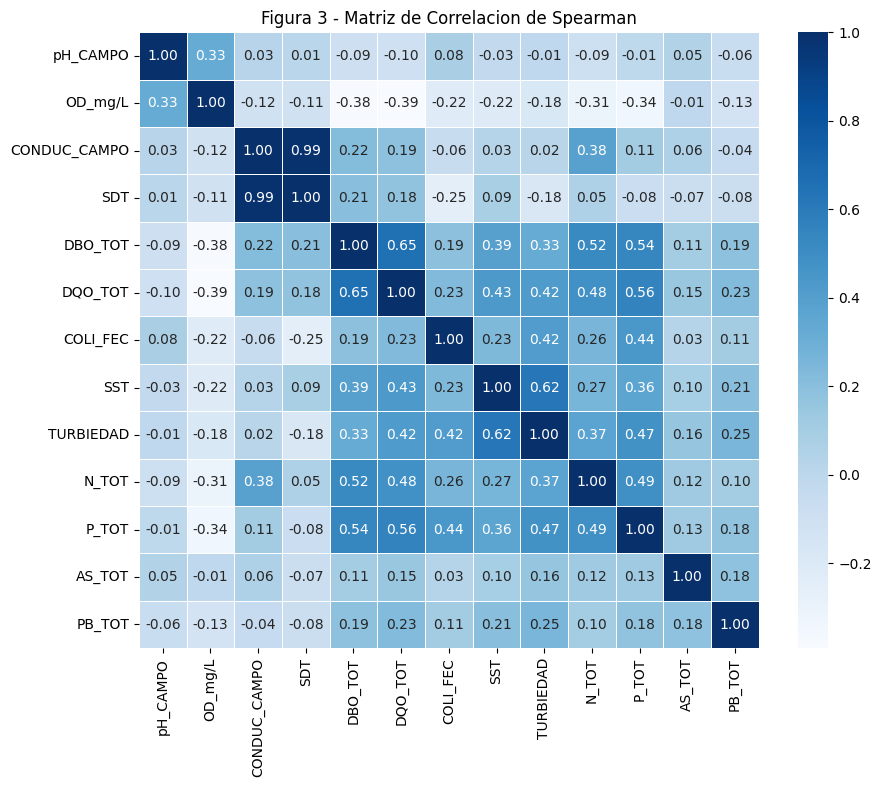

In [10]:
corr = df_eda[cols_num].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Figura 3 - Matriz de Correlacion de Spearman')
plt.show()


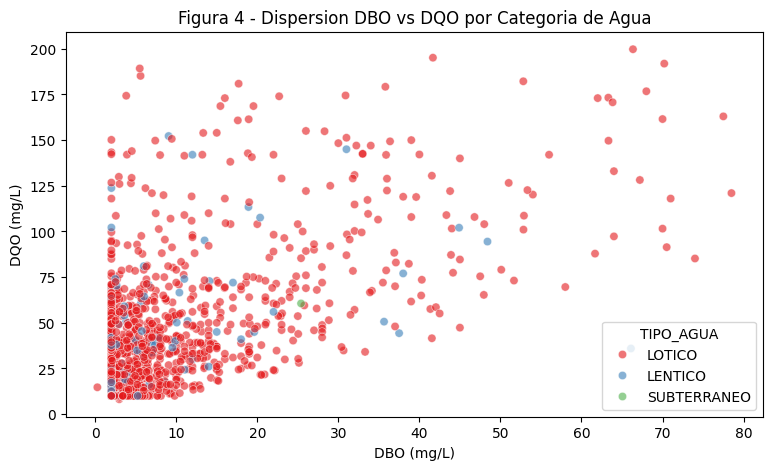

In [11]:
df_multi = df_eda[df_eda['TIPO_AGUA'].isin(['LOTICO', 'LENTICO', 'SUBTERRANEO'])].dropna(subset=['DBO_TOT', 'DQO_TOT', 'TURBIEDAD'])
df_multi = df_multi[(df_multi['DBO_TOT'] < 80) & (df_multi['DQO_TOT'] < 200)].sample(n=min(1500, len(df_multi)), random_state=42)

plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_multi, x='DBO_TOT', y='DQO_TOT', hue='TIPO_AGUA', palette='Set1', alpha=0.6)
plt.title('Figura 4 - Dispersion DBO vs DQO por Categoria de Agua')
plt.xlabel('DBO (mg/L)')
plt.ylabel('DQO (mg/L)')
plt.show()


### Lectura de Vista Multivariada
- Asociacion fuerte entre DBO y DQO con coeficiente 0.83. Conductividad y SDT marcan coeficiente 0.88.
- La diferenciacion por color exhibe agrupamiento de cuerpos loticos en rangos altos de carga residual.


# 7. Cierre del Reporte

### Hallazgos
1. Cuerpos loticos registran las mayores concentraciones de DQO y coliformes en comparacion con fuentes subterraneas.
2. La razon DQO frente a DBO confirma dominancia de descargas organicas biodegradables municipales y agropecuarias.
3. El oxigeno disuelto y el pH presentan estabilidad general, con puntos focales de hipoxia en zonas de descarga.

### Preguntas Abiertas
- Que variacion temporal presentan las cuencas entre periodos secos y lluviosos?
- Cuales zonas especificas sobrepasan los umbrales de metales como arsenico y plomo?
- Existe capacidad de estimar coliformes utilizando lecturas directas de conductividad y turbiedad?

### Correcciones Requeridas
- Conversion uniforme de cadenas con operadores menores o mayores antes del calculo cuantitativo.
- Imputacion selectiva o descarte de atributos con alto porcentaje de celdas vacias como plaguicidas especificos.
- Aplicacion de transformacion logaritmica en variables con asimetria severa como coliformes fecales.
